In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe
try:
    df = pd.read_excel('/content/drive/MyDrive/DA-DOCS/DA-Session Docs/DA_Walmart project Docs/Walmart Global Superstore_Dataset.xlsx')
except Exception as e:
    print(f"Error reading as Excel: {e}")
    # Try reading as CSV with a common encoding if Excel fails
    try:
        df = pd.read_csv('/content/drive/MyDrive/DA-DOCS/DA-Session Docs/DA_Walmart project Docs/Walmart Global Superstore_Dataset.csv', encoding='latin1')
    except Exception as csv_e:
        print(f"Error reading as CSV with latin1 encoding: {csv_e}")
        # Try reading as CSV with a different common encoding
        try:
            df = pd.read_csv('/content/drive/MyDrive/DA-DOCS/DA-Session Docs/DA_Walmart project Docs/Walmart Global Superstore_Dataset.csv', encoding='ISO-8859-1')
        except Exception as csv_e2:
            print(f"Error reading as CSV with ISO-8859-1 encoding: {csv_e2}")
            # If still fails, raise the original error
            raise e


# Inspect the data structure
print('Columns in the dataset:')
print(df.columns)



Columns in the dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')


In [5]:
# Ensure relevant columns exist
required_columns = ['Category', 'Sales', 'Profit', 'Order Date']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' is missing from the dataset.")


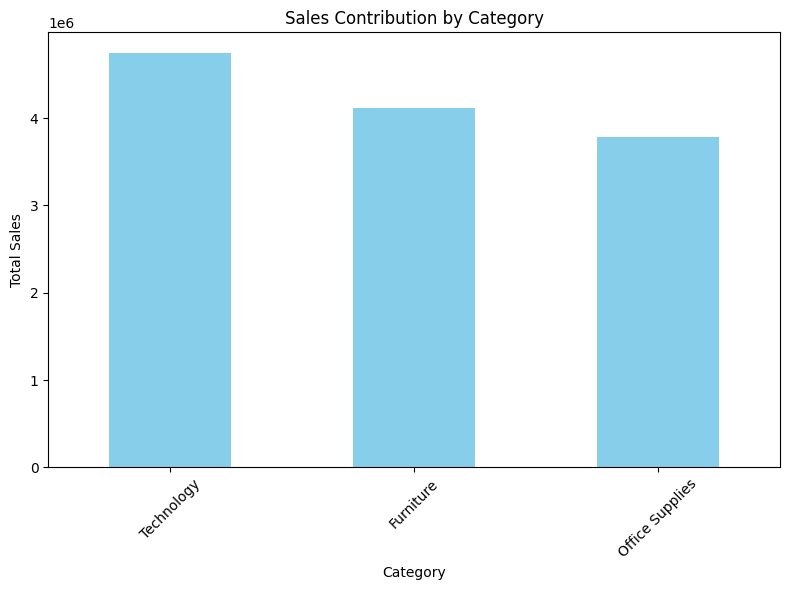

In [6]:
# Sales Contribution by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales Contribution by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

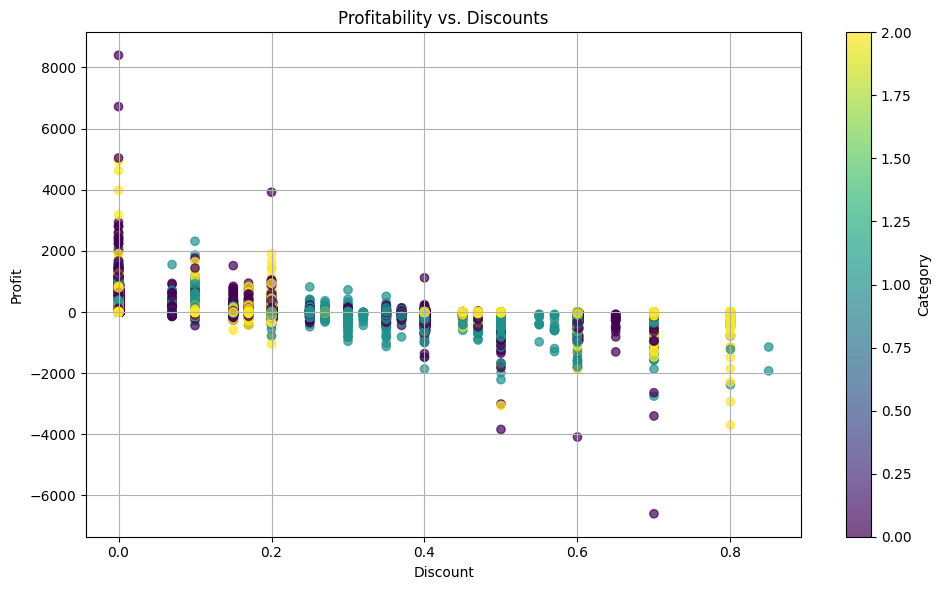

In [7]:
# Profitability vs. Discounts
plt.figure(figsize=(10, 6))
plt.scatter(data=df, x='Discount', y='Profit', c=pd.factorize(df['Category'])[0], cmap='viridis', alpha=0.7)
plt.title('Profitability vs. Discounts')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.colorbar(label='Category')
plt.grid(True)
plt.tight_layout()
plt.show()

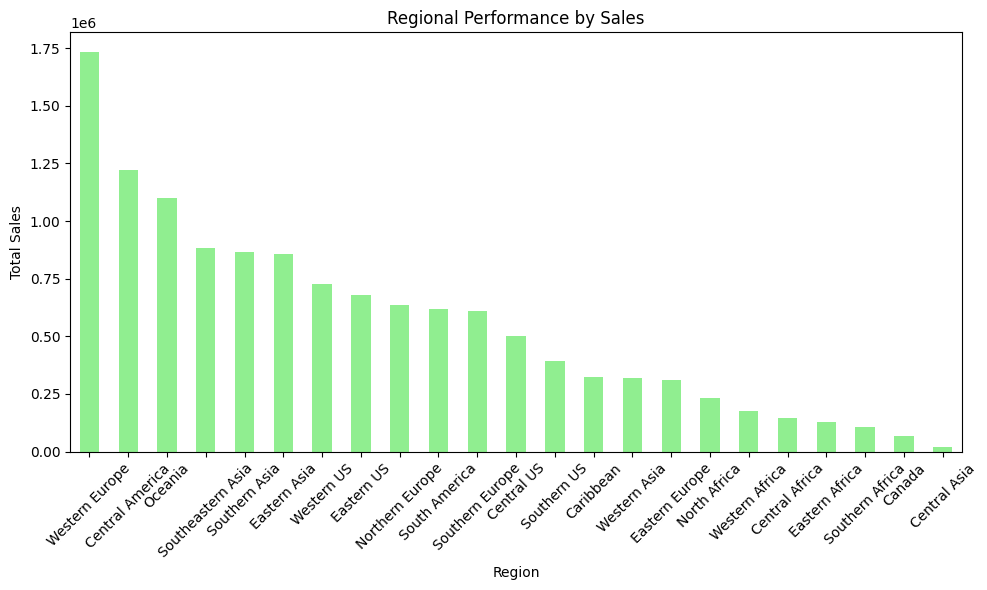

In [8]:
# Regional Performance
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='lightgreen')
plt.title('Regional Performance by Sales')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



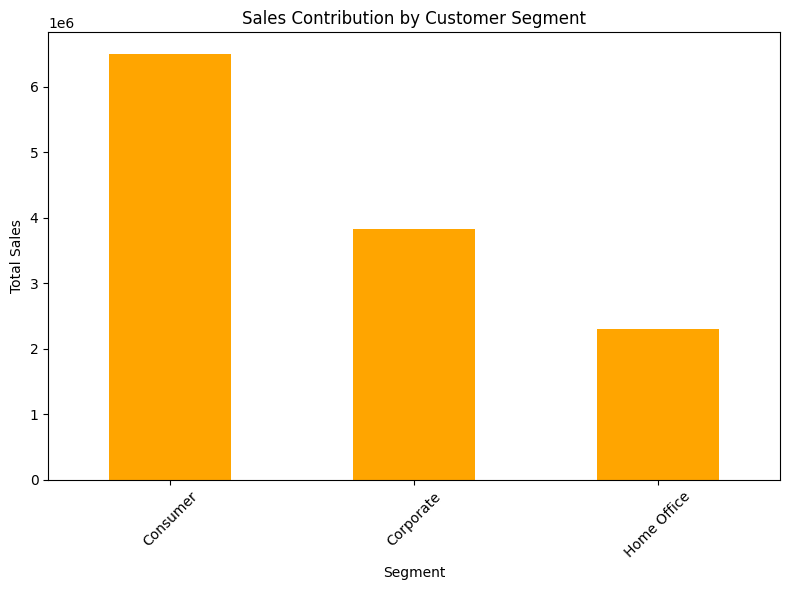

In [9]:
# Customer Segment Behavior
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
segment_sales.plot(kind='bar', color='orange')
plt.title('Sales Contribution by Customer Segment')
plt.ylabel('Total Sales')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


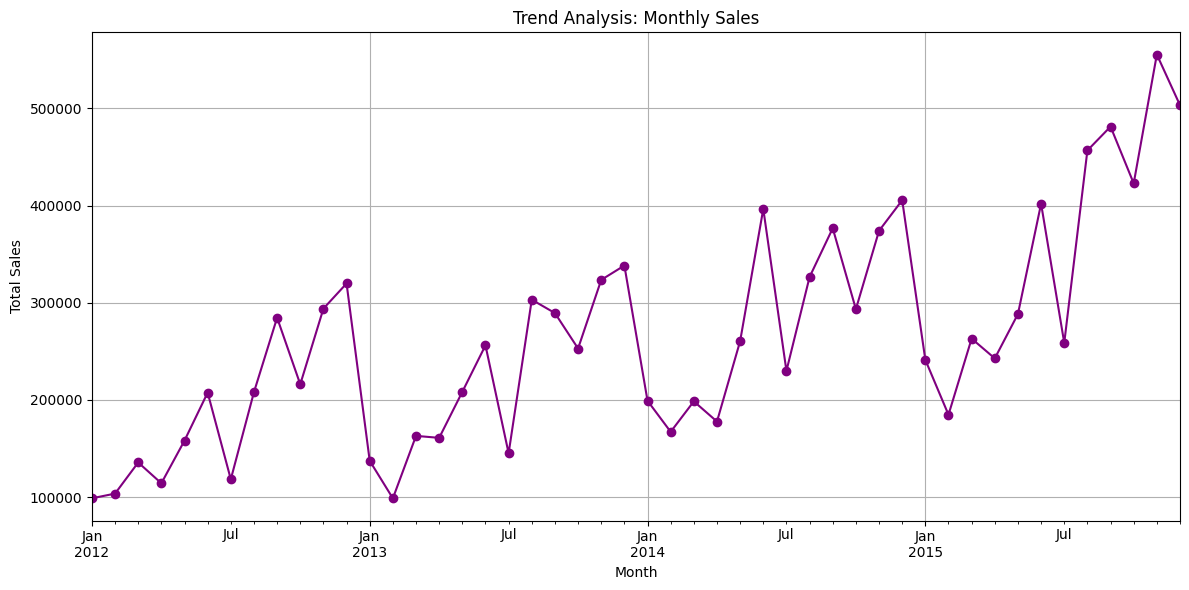

In [10]:
# Trend Analysis (Monthly Sales)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='purple', marker='o')
plt.title('Trend Analysis: Monthly Sales')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_excel('/content/drive/MyDrive/DA-DOCS/DA-Session Docs/DA_Walmart project Docs/Walmart Global Superstore_Dataset.xlsx')
print(df)

       Row ID                  Order ID Order Date  Ship Date       Ship Mode  \
0       40098  CA-2014-AB10015140-41954 2014-11-11 2014-11-13     First Class   
1       26341    IN-2014-JR162107-41675 2014-02-05 2014-02-07    Second Class   
2       25330    IN-2014-CR127307-41929 2014-10-17 2014-10-18     First Class   
3       13524   ES-2014-KM1637548-41667 2014-01-28 2014-01-30     First Class   
4       47221   SG-2014-RH9495111-41948 2014-11-05 2014-11-06        Same Day   
...       ...                       ...        ...        ...             ...   
51285   29002   IN-2015-KE1642066-42174 2015-06-19 2015-06-19        Same Day   
51286   34337  US-2014-ZD21925140-41765 2014-05-06 2014-05-10  Standard Class   
51287   31315  CA-2012-ZD21925140-41147 2012-08-26 2012-08-31    Second Class   
51288    9596   MX-2013-RB1979518-41322 2013-02-17 2013-02-21  Standard Class   
51289    6147   MX-2013-MC1810093-41416 2013-05-22 2013-05-26    Second Class   

        Customer ID       C